In [1]:
from pathlib import Path
import shutil
import sys
import tempfile
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from obspy import read

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "examples" else CWD
REF_EXAMPLES = ROOT.parent / "ref" / "CC-FJpy-master" / "examples"
sys.path.insert(0, str(ROOT))

import ccfj


In [2]:
def extract_zip(zip_path: Path) -> Path:
    tmp_root = Path(tempfile.mkdtemp(prefix="fjpy_win_cc_nb_"))
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp_root)
    return tmp_root


def great_circle_km(p1, p2):
    lat1, lon1 = p1
    lat2, lon2 = p2
    r = 6371.0088
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return float(2.0 * r * np.arcsin(np.sqrt(a)))


def common_day(station_dirs):
    day_sets = []
    for sta_dir in station_dirs:
        days = set()
        for sac in sta_dir.glob("*.SAC"):
            parts = sac.name.split("-")
            if len(parts) >= 4:
                days.add(parts[3])
        if days:
            day_sets.append(days)
    common = set.intersection(*day_sets) if day_sets else set()
    if not common:
        raise RuntimeError("未找到共同日期。")
    return sorted(common)[0]


In [3]:
# 采用与原项目一致的 Crosscorrelation 数据流，但只保留当前 Win 版已验证可运行的主流程。
# 直接使用三台站示例计算互相关，不再混用原项目的按天汇总流程。
src = REF_EXAMPLES / "ThreeStationsCCExample.zip"
tmp_root = extract_zip(src)
data_root = tmp_root / "DataDemo"
station_file = tmp_root / "stations"
station_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])
day = common_day(station_dirs[:3])

coords = {}
for line in station_file.read_text(encoding="utf-8").splitlines():
    parts = line.split()
    if len(parts) >= 3:
        coords[parts[0]] = (float(parts[2]), float(parts[1]))

traces = []
stations = []
for sta_dir in station_dirs[:3]:
    files = sorted(sta_dir.glob(f"*{day}*BHZ.SAC"))
    if not files:
        continue
    tr = read(str(files[0]))[0]
    tr.detrend("demean")
    traces.append(tr)
    stations.append(sta_dir.name)

if len(traces) < 2:
    raise RuntimeError("至少需要两条记录。")

nsta = len(traces)
npts = min(tr.stats.npts for tr in traces)
Fs = float(traces[0].stats.sampling_rate)
fftlen = min(int(Fs * 3600), npts)
nf = min(512, fftlen // 2 + 1)
fstride = 1

data = np.zeros(nsta * npts, dtype=np.float32)
startend = np.zeros(nsta * 2, dtype=np.int32)
for i, tr in enumerate(traces):
    data[i * npts : (i + 1) * npts] = tr.data[:npts].astype(np.float32, copy=False)
    startend[i * 2] = 0
    startend[i * 2 + 1] = npts

pairs = ccfj.GetStationPairs(nsta)
pair_names = []
pair_dist_km = []
for ipair in range(len(pairs) // 2):
    a = int(pairs[2 * ipair])
    b = int(pairs[2 * ipair + 1])
    sta_a = stations[a]
    sta_b = stations[b]
    pair_names.append(f"{sta_a} - {sta_b}")
    pair_dist_km.append(great_circle_km(coords[sta_a], coords[sta_b]))
pair_dist_km = np.asarray(pair_dist_km, dtype=np.float32)
order = np.argsort(pair_dist_km)
ncfs = ccfj.CC(
    npts,
    nsta,
    nf,
    fftlen,
    pairs,
    startend,
    data,
    overlaprate=0.5,
    nThreads=4,
    fstride=fstride,
    ifonebit=0,
    ifspecwhittenning=1,
)
f = np.arange(nf, dtype=np.float32) * Fs / fftlen * fstride
ncfs_sorted = ncfs[order]
pair_dist_sorted = pair_dist_km[order]
pair_names_sorted = [pair_names[i] for i in order]
dt = 1.0 / f[-2] / 2.0
t = (np.linspace(-len(f) - 1, len(f) - 1, 2 * (len(f) - 1)) - 0.5) * dt
ncfst = np.real(np.fft.fftshift(np.fft.irfft(ncfs_sorted, axis=1), axes=1))

summary = {
    "stations": stations,
    "day": day,
    "shape": list(ncfs.shape),
    "abs_max": float(np.max(np.abs(ncfs))),
    "abs_mean": float(np.mean(np.abs(ncfs))),
    "pair_dist_km": [float(x) for x in pair_dist_sorted],
}
summary


{'stations': ['TA-P37A', 'TA-T38A', 'TA-U38A'],
 'day': '200',
 'shape': [3, 512],
 'abs_max': 0.957446813583374,
 'abs_mean': 0.179674431681633,
 'pair_dist_km': [66.7850570678711, 283.9009704589844, 350.145751953125]}

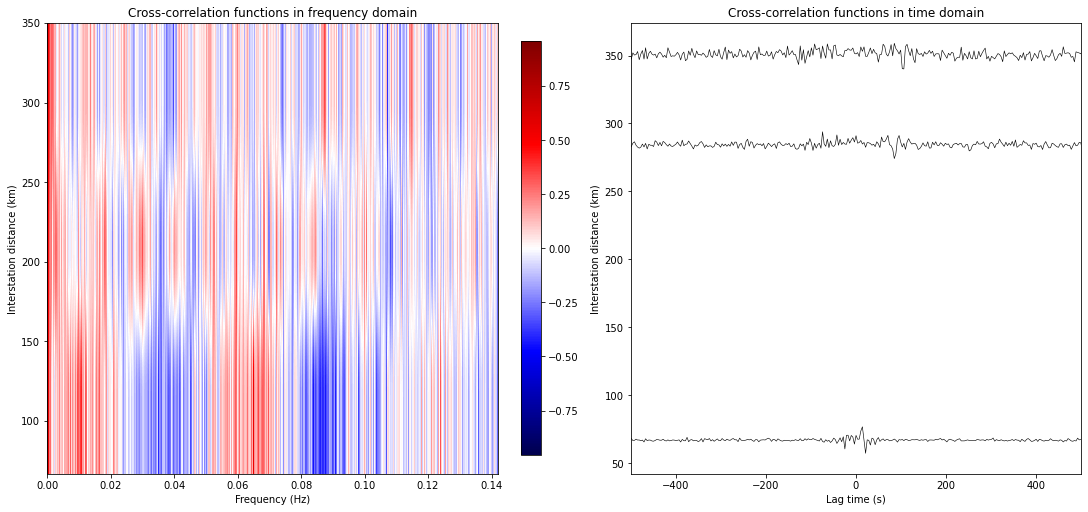

In [4]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 7), constrained_layout=True)
vmax = float(np.max(np.abs(np.real(ncfs_sorted))))
if vmax <= 0:
    vmax = 1.0
im = ax[0].imshow(np.flip(np.real(ncfs_sorted), 0), extent=[float(np.min(f)), float(np.max(f)), float(np.min(pair_dist_sorted)), float(np.max(pair_dist_sorted))], aspect="auto", cmap="seismic", vmin=-vmax, vmax=vmax)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Interstation distance (km)")
ax[0].set_title("Cross-correlation functions in frequency domain")
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

# 时域输出采用原项目常见的剖面展示方式：横轴为延时，纵轴为台间距。
for i in range(len(pair_dist_sorted)):
    curve = ncfst[i, :]
    scale = float(np.max(np.abs(curve)))
    if scale > 0:
        ax[1].plot(t, curve / scale * 10.0 + pair_dist_sorted[i], "k", linewidth=0.6)
ax[1].set_xlim([-500, 500])
ax[1].set_xlabel("Lag time (s)")
ax[1].set_ylabel("Interstation distance (km)")
ax[1].set_title("Cross-correlation functions in time domain")
plt.show()


In [5]:
shutil.rmtree(tmp_root, ignore_errors=True)
print("中文自检：互相关 notebook 已按 UTF-8 写入。")


中文自检：互相关 notebook 已按 UTF-8 写入。
